In [15]:
# ============================================================
# 1. Imports
# ============================================================
import json
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from contextlib import nullcontext
from torch.utils.data import Dataset, DataLoader
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

# ============================================================
# 2. Device Setup
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# 3. Load Training Data  (unchanged)
# ============================================================
with open('/content/train.json') as f:
    raw = json.load(f)

def build_story(item):
    return ' '.join([
        item.get('precontext', ''),
        item.get('sentence', ''),
        item.get('ending', '')
    ])

def build_meaning(item):
    return item.get('judged_meaning', '')

items    = list(raw.values())
stories  = [build_story(i)  for i in items]
meanings = [build_meaning(i) for i in items]
labels   = np.array([i['average'] for i in items], dtype=np.float32)
stdevs   = np.array([i['stdev']   for i in items], dtype=np.float32)

# ============================================================
# 4. Tokenization  (unchanged)
# ============================================================
MAX_WORDS = 10000
MAX_LEN   = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(stories + meanings)

X_story = pad_sequences(
    tokenizer.texts_to_sequences(stories),
    maxlen=MAX_LEN, padding='post'
)
X_mean = pad_sequences(
    tokenizer.texts_to_sequences(meanings),
    maxlen=MAX_LEN, padding='post'
)

Xs_train, Xs_val, Xm_train, Xm_val, y_train, y_val, s_train, s_val = train_test_split(
    X_story, X_mean, labels, stdevs,
    test_size=0.15, random_state=42
)

# ============================================================
# 5. Load GloVe Embeddings  (unchanged)
# ============================================================
GLOVE_PATH = '/content/glove.6B.100d.txt'
EMBED_DIM  = 100

if not os.path.exists(GLOVE_PATH):
    raise FileNotFoundError("Download GloVe first: glove.6B.100d.txt")

embeddings_index = {}
with open(GLOVE_PATH, encoding='utf8') as f:
    for line in f:
        values = line.split()
        embeddings_index[values[0]] = np.asarray(values[1:], dtype='float32')

word_index = tokenizer.word_index
num_words  = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBED_DIM), dtype=np.float32)
for word, i in word_index.items():
    if i < num_words and word in embeddings_index:
        embedding_matrix[i] = embeddings_index[word]

# ============================================================
# 6. Dataset
# ============================================================
class AmbiStoryDataset(Dataset):
    def __init__(self, X_story, X_mean, labels, stdevs):
        self.X_story = torch.tensor(X_story, dtype=torch.long)
        self.X_mean  = torch.tensor(X_mean,  dtype=torch.long)
        self.labels  = torch.tensor(labels,  dtype=torch.float32)
        self.stdevs  = torch.tensor(stdevs,  dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.X_story[idx],
            self.X_mean[idx],
            self.labels[idx],
            self.stdevs[idx]
        )

train_dataset = AmbiStoryDataset(Xs_train, Xm_train, y_train, s_train)
val_dataset   = AmbiStoryDataset(Xs_val,   Xm_val,   y_val,   s_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=(device.type == 'cuda'),
    num_workers=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=(device.type == 'cuda'),
    num_workers=2
)

# ============================================================
# 7. Encoder (BiSimpleRNN — no attention, GloVe trainable)
# ============================================================
class BiRNNEncoder(nn.Module):
    def __init__(self, num_words, embed_dim, embedding_matrix,
                 rnn_units, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(num_words, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )                                           # GloVe weights, trainable

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=rnn_units,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)                       # (B, L, E)
        x = self.dropout(x)
        out, _ = self.rnn(x)                        # (B, L, 2*rnn_units)
        x = out.mean(dim=1)                         # GlobalAveragePooling equivalent
        return x

# ============================================================
# 8. Dual-Encoder Model
# ============================================================
class DualEncoderModel(nn.Module):
    def __init__(self, num_words, embed_dim, embedding_matrix,
                 rnn_units=128, num_layers=1, dropout=0.3,
                 dense_units=128):
        super().__init__()

        encoder_args = (num_words, embed_dim, embedding_matrix,
                        rnn_units, num_layers, dropout)

        self.story_encoder   = BiRNNEncoder(*encoder_args)
        self.meaning_encoder = BiRNNEncoder(*encoder_args)

        combined_dim = rnn_units * 2 * 3            # story + meaning + |diff|

        self.head = nn.Sequential(
            nn.Linear(combined_dim, dense_units),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(dense_units, 1)
        )

    def forward(self, story, meaning):
        sv       = self.story_encoder(story)        # (B, 2*rnn_units)
        mv       = self.meaning_encoder(meaning)    # (B, 2*rnn_units)
        diff     = torch.abs(sv - mv)
        combined = torch.cat([sv, mv, diff], dim=1) # (B, 6*rnn_units)
        return self.head(combined).squeeze(1)       # (B,)

# ============================================================
# 9. Huber Loss  (delta=1.0 — equivalent to keras.losses.Huber)
# ============================================================
# Huber is less sensitive to outliers than MSE:
#   |error| <= delta  →  0.5 * error^2          (quadratic zone)
#   |error|  > delta  →  delta * (|error| - 0.5 * delta)  (linear zone)
huber_loss_fn = nn.HuberLoss(reduction='mean', delta=1.0)

# ============================================================
# 10. Training Loop
# ============================================================
def get_amp_autocast(device):
    if device.type != 'cuda':
        return nullcontext()
    if hasattr(torch, 'autocast'):
        return torch.autocast(device_type='cuda', dtype=torch.float16, enabled=True)
    return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)


def get_grad_scaler(device):
    amp_enabled = (device.type == 'cuda')
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
        return torch.amp.GradScaler(device.type, enabled=amp_enabled)
    return torch.cuda.amp.GradScaler(enabled=amp_enabled)


def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0.0

    for story, meaning, label, _ in loader:        # stdev not needed for Huber
        story   = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        label   = label.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with get_amp_autocast(device):
            preds = model(story, meaning)
            loss  = huber_loss_fn(preds, label)     # Huber(delta=1.0)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate_epoch(model, loader):
    model.eval()
    total_loss = 0.0

    for story, meaning, label, _ in loader:
        story   = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        label   = label.to(device, non_blocking=True)

        preds      = model(story, meaning)
        total_loss += huber_loss_fn(preds, label).item()

    return total_loss / len(loader)

# ============================================================
# 11. Instantiate Model, Optimizer, Scheduler
#     lr slightly reduced to 5e-4 for stability with Huber
# ============================================================
model = DualEncoderModel(
    num_words=num_words,
    embed_dim=EMBED_DIM,
    embedding_matrix=embedding_matrix,
    rnn_units=128,
    num_layers=1,
    dropout=0.3,
    dense_units=128
).to(device)

optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
# lr reduced to 5e-4 vs 1e-3 — Huber's linear region produces larger raw gradients
# than MSE near the mean, so a modest lr reduction improves stability

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)
scaler = get_grad_scaler(device)

# ============================================================
# 12. Run Training with Early Stopping
# ============================================================
EPOCHS        = 30
PATIENCE      = 5
best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
    val_loss   = evaluate_epoch(model, val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:02d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})

# ============================================================
# 13. Evaluation (SemEval Metrics — unchanged)
# ============================================================
@torch.no_grad()
def evaluate(model, Xs, Xm, y=None, s=None, compute_metrics=True):
    model.eval()
    if y is None:
        y = np.zeros(len(Xs), dtype=np.float32)
    if s is None:
        s = np.ones(len(Xs), dtype=np.float32)

    ds     = AmbiStoryDataset(Xs, Xm, y, s)
    loader = DataLoader(ds, batch_size=64, shuffle=False,
                        pin_memory=(device.type == 'cuda'))

    all_preds = []
    for story, meaning, _, _ in loader:
        story   = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        preds   = model(story, meaning)
        all_preds.append(preds.cpu().numpy())

    preds = np.clip(np.concatenate(all_preds), 1, 5)
    if compute_metrics:
        s = np.maximum(s, 1.0)

        sp = spearmanr(y, preds).correlation
        print("Spearman r           :", sp)
        print("Accuracy within std  :", np.mean(np.abs(preds - y) <= s))
    return preds

print("\n── Validation Results ──")
val_preds = evaluate(model, Xs_val, Xm_val, y_val, s_val)

# ============================================================
# 14. Predict on Test Set
# ============================================================
with open('/content/test.json') as f:
    test_raw = json.load(f)

test_items = list(test_raw.values())
test_story = pad_sequences(
    tokenizer.texts_to_sequences([build_story(i)  for i in test_items]),
    maxlen=MAX_LEN, padding='post'
)
test_mean = pad_sequences(
    tokenizer.texts_to_sequences([build_meaning(i) for i in test_items]),
    maxlen=MAX_LEN, padding='post'
)

dummy_labels = np.ones(len(test_items), dtype=np.float32)
dummy_stdevs = np.ones(len(test_items), dtype=np.float32)

test_preds = evaluate(
    model,
    test_story,
    test_mean,
    dummy_labels,
    dummy_stdevs,
    compute_metrics=False
)

print("\nSample Test Predictions:")
for i in range(min(10, len(test_preds))):
    print(f"Sample {i+1}: {test_preds[i]:.3f}")

Using device: cuda
  GPU : Tesla T4
  VRAM: 15.6 GB
Epoch 01 | train_loss: 1.0215 | val_loss: 0.6465
Epoch 02 | train_loss: 0.6454 | val_loss: 0.6421
Epoch 03 | train_loss: 0.6627 | val_loss: 0.6345
Epoch 04 | train_loss: 0.6260 | val_loss: 0.6395
Epoch 05 | train_loss: 0.6348 | val_loss: 0.6319
Epoch 06 | train_loss: 0.6365 | val_loss: 0.6356
Epoch 07 | train_loss: 0.6323 | val_loss: 0.6343
Epoch 08 | train_loss: 0.6272 | val_loss: 0.6235
Epoch 09 | train_loss: 0.6165 | val_loss: 0.6423
Epoch 10 | train_loss: 0.6286 | val_loss: 0.6170
Epoch 11 | train_loss: 0.6014 | val_loss: 0.6501
Epoch 12 | train_loss: 0.6046 | val_loss: 0.5937
Epoch 13 | train_loss: 0.5701 | val_loss: 0.5952
Epoch 14 | train_loss: 0.5480 | val_loss: 0.5730
Epoch 15 | train_loss: 0.5218 | val_loss: 0.5791
Epoch 16 | train_loss: 0.5275 | val_loss: 0.6077
Epoch 17 | train_loss: 0.5075 | val_loss: 0.5926
Epoch 18 | train_loss: 0.4937 | val_loss: 0.6183
Epoch 19 | train_loss: 0.4698 | val_loss: 0.6213
Early stopping at

Spearman r           : 0.24470838919171922
Accuracy within std  : 0.6081871345029239


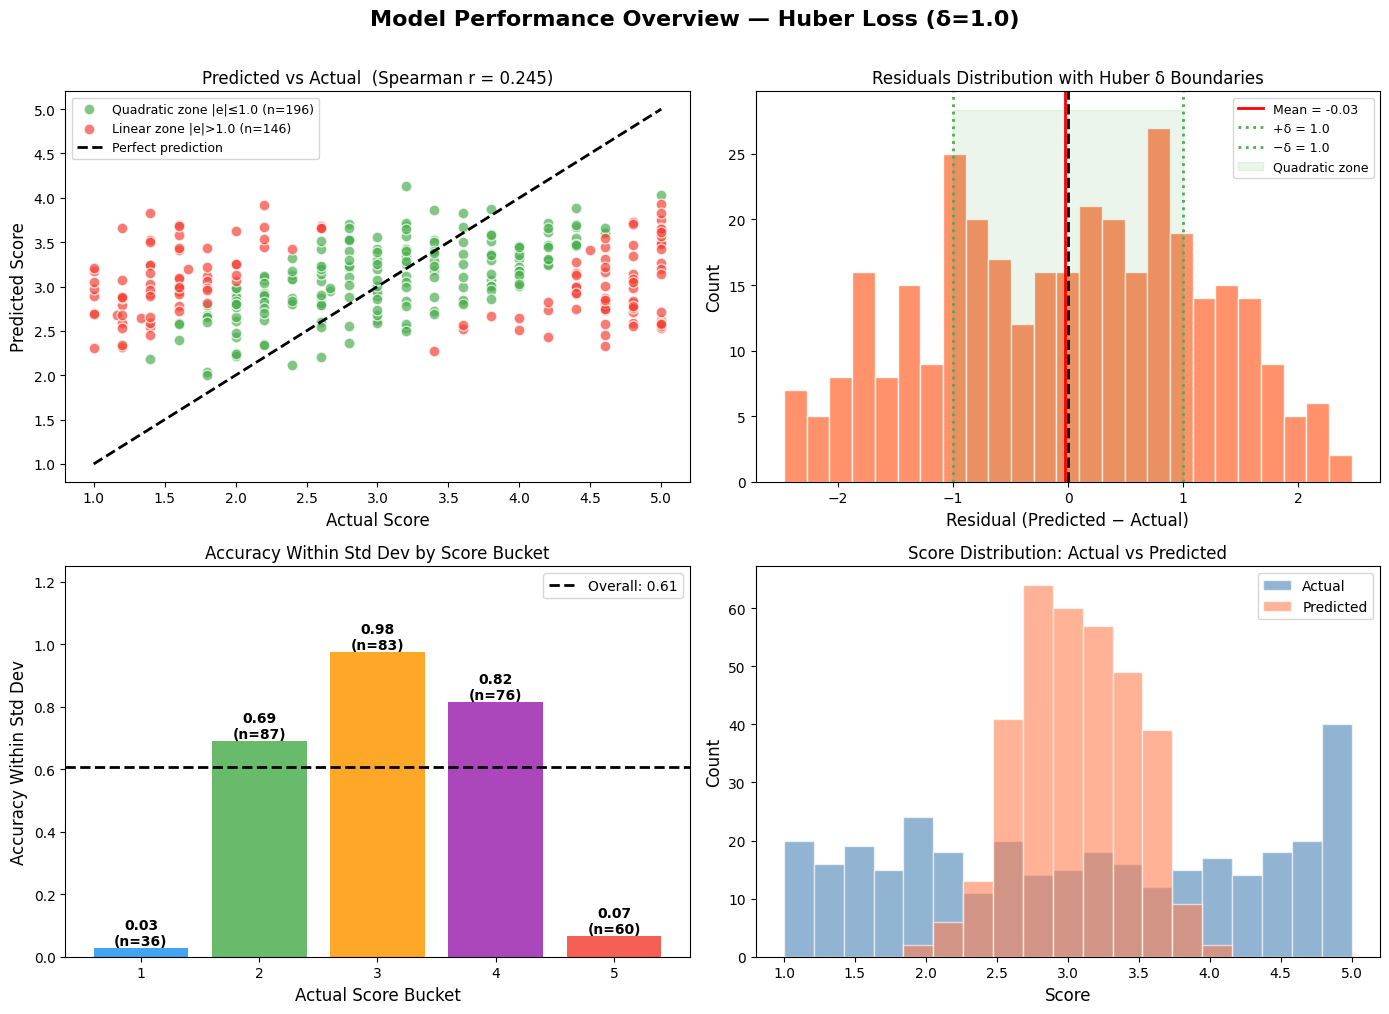

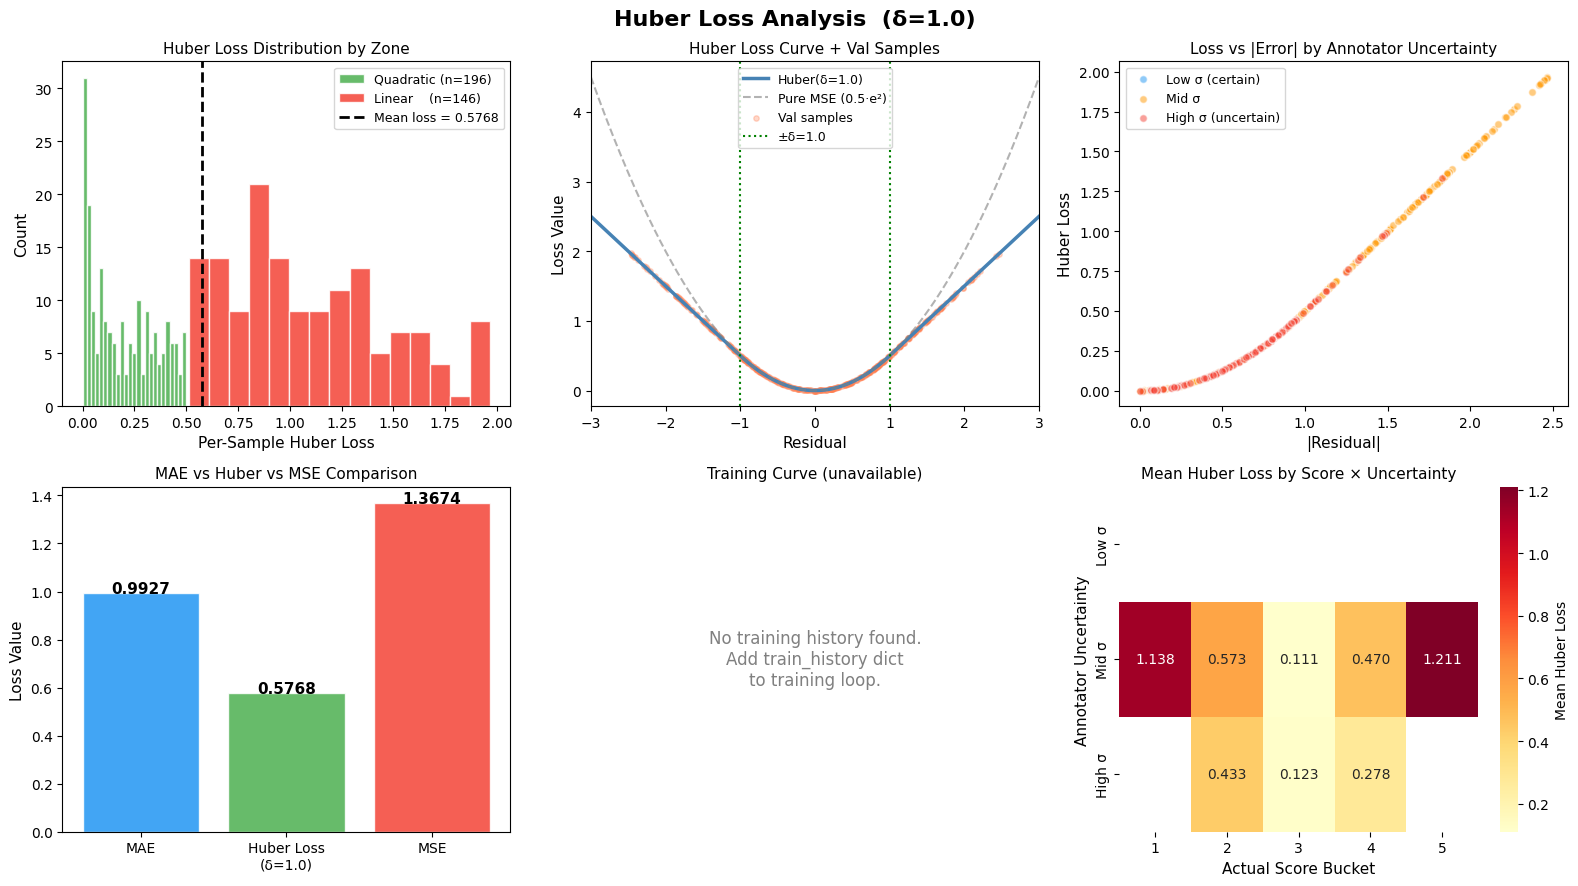

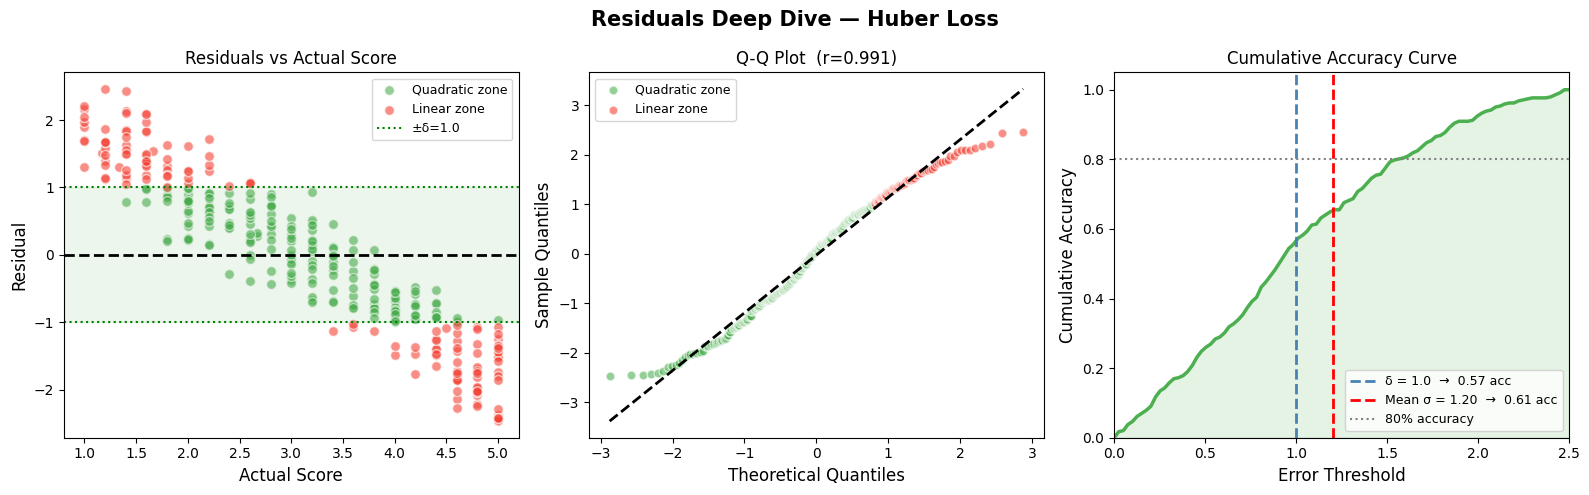

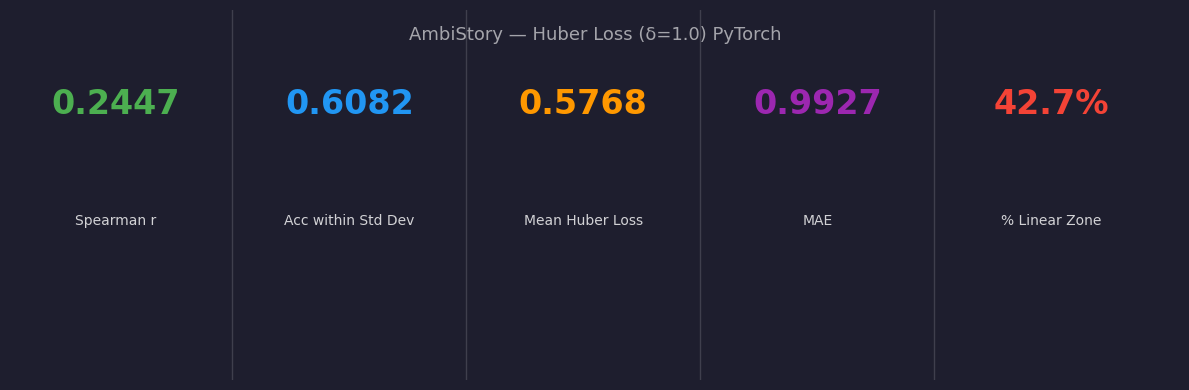


✓ Saved:
  /content/performance_overview.png
  /content/huber_loss_analysis.png
  /content/residuals_deep_dive.png
  /content/summary_card.png


In [16]:
# ============================================================
# Visualization — Huber Loss (PyTorch)
# Run AFTER training. Requires: model, Xs_val, Xm_val, y_val, s_val
#                               train_history (optional)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import spearmanr

DELTA = 1.0   # must match HuberLoss(delta=...) used in training

# ── Collect val predictions ────────────────────────────────────────────────
val_preds = evaluate(model, Xs_val, Xm_val, y_val, s_val)   # clipped [1,5]
stdevs    = np.maximum(s_val, 1.0)
residuals = val_preds - y_val
abs_res   = np.abs(residuals)
within    = abs_res <= stdevs
spear     = spearmanr(y_val, val_preds).correlation
mae_val   = abs_res.mean()

# Huber zone masks  (used across multiple panels)
quadratic_mask = abs_res <= DELTA                             # |e| ≤ δ  →  0.5·e²
linear_mask    = abs_res >  DELTA                             # |e| > δ  →  δ·(|e| - 0.5·δ)

def huber_elementwise(e, delta=DELTA):
    """Per-sample Huber loss values for analysis."""
    loss = np.where(
        np.abs(e) <= delta,
        0.5 * e**2,
        delta * (np.abs(e) - 0.5 * delta)
    )
    return loss

sample_huber = huber_elementwise(residuals)

has_history = 'train_history' in globals()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Model Performance Overview
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Overview — Huber Loss (δ=1.0)',
             fontsize=16, fontweight='bold', y=1.01)

# ── 1. Predicted vs Actual (coloured by Huber zone) ───────────────────────
ax = axes[0, 0]
ax.scatter(y_val[quadratic_mask], val_preds[quadratic_mask],
           alpha=0.7, color='#4CAF50', edgecolors='white', s=60,
           label=f'Quadratic zone |e|≤{DELTA} (n={quadratic_mask.sum()})')
ax.scatter(y_val[linear_mask], val_preds[linear_mask],
           alpha=0.7, color='#F44336', edgecolors='white', s=60,
           label=f'Linear zone |e|>{DELTA} (n={linear_mask.sum()})')
ax.plot([1, 5], [1, 5], 'k--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Score',    fontsize=12)
ax.set_ylabel('Predicted Score', fontsize=12)
ax.set_title(f'Predicted vs Actual  (Spearman r = {spear:.3f})', fontsize=12)
ax.legend(fontsize=9); ax.set_xlim(0.8, 5.2); ax.set_ylim(0.8, 5.2)

# ── 2. Residuals Distribution with Huber δ boundaries ────────────────────
ax = axes[0, 1]
ax.hist(residuals, bins=25, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(0,               color='black', linestyle='--', lw=2)
ax.axvline(residuals.mean(), color='red',   linestyle='-',  lw=2,
           label=f'Mean = {residuals.mean():.2f}')
ax.axvline( DELTA, color='#4CAF50', linestyle=':', lw=2,
           label=f'+δ = {DELTA:.1f}')
ax.axvline(-DELTA, color='#4CAF50', linestyle=':', lw=2,
           label=f'−δ = {DELTA:.1f}')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 100],
                  -DELTA, DELTA, alpha=0.08, color='green',
                  label='Quadratic zone')
ax.set_xlabel('Residual (Predicted − Actual)', fontsize=12)
ax.set_ylabel('Count',                         fontsize=12)
ax.set_title('Residuals Distribution with Huber δ Boundaries', fontsize=12)
ax.legend(fontsize=9)

# ── 3. Accuracy Within Std Dev per Score Bucket ───────────────────────────
ax = axes[1, 0]
buckets    = [1, 2, 3, 4, 5]
bucket_acc = []
bucket_n   = []
for b in buckets:
    mask = (np.round(y_val) == b)
    bucket_acc.append(within[mask].mean() if mask.sum() > 0 else 0)
    bucket_n.append(mask.sum())

colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
bars   = ax.bar([str(b) for b in buckets], bucket_acc,
                color=colors, alpha=0.85)
ax.axhline(within.mean(), color='black', linestyle='--', lw=2,
           label=f'Overall: {within.mean():.2f}')
for bar, val, n in zip(bars, bucket_acc, bucket_n):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}\n(n={n})', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Actual Score Bucket',     fontsize=12)
ax.set_ylabel('Accuracy Within Std Dev', fontsize=12)
ax.set_title('Accuracy Within Std Dev by Score Bucket', fontsize=12)
ax.set_ylim(0, 1.25); ax.legend()

# ── 4. Score Distribution: Actual vs Predicted ────────────────────────────
ax = axes[1, 1]
bins = np.linspace(1, 5, 20)
ax.hist(y_val,     bins=bins, alpha=0.6, color='steelblue',
        label='Actual',    edgecolor='white')
ax.hist(val_preds, bins=bins, alpha=0.6, color='coral',
        label='Predicted', edgecolor='white')
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Score Distribution: Actual vs Predicted', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('/content/performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Huber Loss Analysis (replaces Gaussian Weight Analysis)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Huber Loss Analysis  (δ=1.0)', fontsize=16, fontweight='bold')

# ── 1. Per-Sample Huber Loss Distribution ─────────────────────────────────
ax = axes[0, 0]
ax.hist(sample_huber[quadratic_mask], bins=25, color='#4CAF50',
        edgecolor='white', alpha=0.85, label=f'Quadratic (n={quadratic_mask.sum()})')
ax.hist(sample_huber[linear_mask],    bins=15, color='#F44336',
        edgecolor='white', alpha=0.85, label=f'Linear    (n={linear_mask.sum()})')
ax.axvline(sample_huber.mean(), color='black', lw=2, linestyle='--',
           label=f'Mean loss = {sample_huber.mean():.4f}')
ax.set_xlabel('Per-Sample Huber Loss', fontsize=11)
ax.set_ylabel('Count',                 fontsize=11)
ax.set_title('Huber Loss Distribution by Zone', fontsize=11)
ax.legend(fontsize=9)

# ── 2. Huber Loss Curve with sample overlay ───────────────────────────────
ax = axes[0, 1]
e_range = np.linspace(-3, 3, 300)
h_curve = huber_elementwise(e_range)
ax.plot(e_range, h_curve, color='steelblue', lw=2.5, label='Huber(δ=1.0)')
ax.plot(e_range, 0.5*e_range**2, color='gray', lw=1.5,
        linestyle='--', alpha=0.6, label='Pure MSE (0.5·e²)')
ax.scatter(residuals, sample_huber, alpha=0.3, color='coral',
           s=15, label='Val samples')
ax.axvline( DELTA, color='green', lw=1.5, linestyle=':', label=f'±δ={DELTA}')
ax.axvline(-DELTA, color='green', lw=1.5, linestyle=':')
ax.set_xlabel('Residual',          fontsize=11)
ax.set_ylabel('Loss Value',        fontsize=11)
ax.set_title('Huber Loss Curve + Val Samples', fontsize=11)
ax.set_xlim(-3, 3); ax.legend(fontsize=9)

# ── 3. Huber Loss vs Absolute Error (by stdev bucket) ────────────────────
ax = axes[0, 2]
stdev_bins   = np.percentile(stdevs, [0, 33, 66, 100])
stdev_colors = ['#2196F3', '#FF9800', '#F44336']
stdev_labels = ['Low σ (certain)', 'Mid σ', 'High σ (uncertain)']
for si in range(3):
    if si < 2:
        smask = (stdevs >= stdev_bins[si]) & (stdevs < stdev_bins[si+1])
    else:
        smask = (stdevs >= stdev_bins[si]) & (stdevs <= stdev_bins[si+1])
    ax.scatter(abs_res[smask], sample_huber[smask],
               alpha=0.5, color=stdev_colors[si], s=30,
               edgecolors='white', label=stdev_labels[si])
ax.set_xlabel('|Residual|',          fontsize=11)
ax.set_ylabel('Huber Loss',          fontsize=11)
ax.set_title('Loss vs |Error| by Annotator Uncertainty', fontsize=11)
ax.legend(fontsize=9)

# ── 4. Huber vs MSE vs MAE comparison ─────────────────────────────────────
ax = axes[1, 0]
mse_val  = np.mean(residuals**2)
mean_hub = sample_huber.mean()

metric_names = ['MAE', 'Huber Loss\n(δ=1.0)', 'MSE']
metric_vals  = [mae_val, mean_hub, mse_val]
bar_colors   = ['#2196F3', '#4CAF50', '#F44336']

bars = ax.bar(metric_names, metric_vals,
              color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_ylabel('Loss Value', fontsize=11)
ax.set_title('MAE vs Huber vs MSE Comparison', fontsize=11)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# ── 5. Training Curve ─────────────────────────────────────────────────────
ax = axes[1, 1]
if has_history:
    epochs_range = range(1, len(train_history['train_loss']) + 1)
    ax.plot(epochs_range, train_history['train_loss'],
            color='steelblue', lw=2, label='Train Loss')
    ax.plot(epochs_range, train_history['val_loss'],
            color='coral',     lw=2, linestyle='--', label='Val Loss')
    # Mark best epoch
    best_ep = int(np.argmin(train_history['val_loss'])) + 1
    best_vl = min(train_history['val_loss'])
    ax.axvline(best_ep, color='green', lw=1.5, linestyle=':',
               label=f'Best epoch={best_ep}  loss={best_vl:.4f}')
    ax.set_xlabel('Epoch',  fontsize=11)
    ax.set_ylabel('Loss',   fontsize=11)
    ax.set_title('Training & Validation Loss (Huber)', fontsize=11)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5,
            'No training history found.\nAdd train_history dict\nto training loop.',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='gray')
    ax.set_title('Training Curve (unavailable)', fontsize=11)
    ax.axis('off')

# ── 6. Mean Huber Loss Heatmap by (score_bucket × stdev_bucket) ───────────
ax = axes[1, 2]
score_buckets = [1, 2, 3, 4, 5]
heatmap_data  = np.full((3, len(score_buckets)), np.nan)
for si in range(3):
    if si < 2:
        smask = (stdevs >= stdev_bins[si]) & (stdevs < stdev_bins[si+1])
    else:
        smask = (stdevs >= stdev_bins[si]) & (stdevs <= stdev_bins[si+1])
    for bi, b in enumerate(score_buckets):
        bmask = (np.round(y_val) == b)
        mask  = smask & bmask
        heatmap_data[si, bi] = sample_huber[mask].mean() if mask.sum() > 0 else np.nan

sns.heatmap(heatmap_data, ax=ax,
            xticklabels=score_buckets,
            yticklabels=['Low σ', 'Mid σ', 'High σ'],
            annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'Mean Huber Loss'})
ax.set_xlabel('Actual Score Bucket',   fontsize=11)
ax.set_ylabel('Annotator Uncertainty', fontsize=11)
ax.set_title('Mean Huber Loss by Score × Uncertainty', fontsize=11)

plt.tight_layout()
plt.savefig('/content/huber_loss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Residuals Deep Dive
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Residuals Deep Dive — Huber Loss', fontsize=15, fontweight='bold')

# ── 1. Residuals vs Actual Score (Huber zone coloured) ────────────────────
ax = axes[0]
ax.scatter(y_val[quadratic_mask], residuals[quadratic_mask],
           color='#4CAF50', alpha=0.6, s=50, edgecolors='white',
           label='Quadratic zone')
ax.scatter(y_val[linear_mask], residuals[linear_mask],
           color='#F44336', alpha=0.6, s=50, edgecolors='white',
           label='Linear zone')
ax.axhline(0,      color='black', lw=2,   linestyle='--')
ax.axhline( DELTA, color='green', lw=1.5, linestyle=':',  label=f'±δ={DELTA}')
ax.axhline(-DELTA, color='green', lw=1.5, linestyle=':')
ax.fill_between([0.8, 5.2], -DELTA, DELTA,
                alpha=0.07, color='green')
ax.set_xlabel('Actual Score',             fontsize=12)
ax.set_ylabel('Residual',                 fontsize=12)
ax.set_title('Residuals vs Actual Score', fontsize=12)
ax.set_xlim(0.8, 5.2); ax.legend(fontsize=9)

# ── 2. Q-Q Plot of Residuals ──────────────────────────────────────────────
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax.scatter(osm[np.array(osr) <= DELTA],  np.array(osr)[np.array(osr) <= DELTA],
           color='#4CAF50', alpha=0.6, s=40, edgecolors='white',
           label='Quadratic zone')
ax.scatter(osm[np.array(osr) > DELTA],   np.array(osr)[np.array(osr) > DELTA],
           color='#F44336', alpha=0.6, s=40, edgecolors='white',
           label='Linear zone')
ax.plot(osm, slope * np.array(osm) + intercept, 'k--', lw=2)
ax.set_xlabel('Theoretical Quantiles', fontsize=12)
ax.set_ylabel('Sample Quantiles',      fontsize=12)
ax.set_title(f'Q-Q Plot  (r={r:.3f})',  fontsize=12)
ax.legend(fontsize=9)

# ── 3. Cumulative Accuracy Curve ──────────────────────────────────────────
ax = axes[2]
thresholds = np.linspace(0, 2.5, 100)
cum_acc    = [np.mean(abs_res <= t) for t in thresholds]
ax.plot(thresholds, cum_acc, color='#4CAF50', lw=2.5)
ax.axvline(DELTA, color='steelblue', lw=2, linestyle='--',
           label=f'δ = {DELTA}  →  {np.mean(abs_res <= DELTA):.2f} acc')
ax.axvline(stdevs.mean(), color='red', lw=2, linestyle='--',
           label=f'Mean σ = {stdevs.mean():.2f}  →  {within.mean():.2f} acc')
ax.axhline(0.8, color='gray', lw=1.5, linestyle=':', label='80% accuracy')
ax.fill_between(thresholds, cum_acc, alpha=0.15, color='#4CAF50')
ax.set_xlabel('Error Threshold',          fontsize=12)
ax.set_ylabel('Cumulative Accuracy',      fontsize=12)
ax.set_title('Cumulative Accuracy Curve', fontsize=12)
ax.set_xlim(0, 2.5); ax.set_ylim(0, 1.05); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/residuals_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Summary Card
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(12, 4))
fig.patch.set_facecolor('#1E1E2E')
ax  = fig.add_subplot(111)
ax.set_facecolor('#1E1E2E'); ax.axis('off')

pct_linear = linear_mask.mean() * 100
metrics = [
    ('Spearman r',         f'{spear:.4f}',          '#4CAF50'),
    ('Acc within Std Dev', f'{within.mean():.4f}',  '#2196F3'),
    ('Mean Huber Loss',    f'{sample_huber.mean():.4f}', '#FF9800'),
    ('MAE',                f'{mae_val:.4f}',         '#9C27B0'),
    ('% Linear Zone',      f'{pct_linear:.1f}%',     '#F44336'),
]

for i, (label, value, color) in enumerate(metrics):
    x = 0.09 + i * 0.20
    ax.text(x, 0.72, value, transform=ax.transAxes,
            fontsize=24, fontweight='bold', color=color, ha='center')
    ax.text(x, 0.42, label, transform=ax.transAxes,
            fontsize=10, color='white', ha='center', alpha=0.8)
    if i < len(metrics) - 1:
        ax.axvline(x + 0.10, color='white', alpha=0.15, lw=1)

ax.text(0.5, 0.92, 'AmbiStory — Huber Loss (δ=1.0) PyTorch',
        transform=ax.transAxes, fontsize=13, color='white',
        ha='center', alpha=0.6)

plt.tight_layout()
plt.savefig('/content/summary_card.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print("\n✓ Saved:")
print("  /content/performance_overview.png")
print("  /content/huber_loss_analysis.png")
print("  /content/residuals_deep_dive.png")
print("  /content/summary_card.png")